In [ ]:
!pip install xgboost

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

/usr/local/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [08:00:58] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


 [1차 모델 평가 결과] 

정확도(Accuracy): 0.9704

분류 리포트(Classification Report):
              precision    recall  f1-score   support

           0       0.92      0.90      0.91       325
           1       0.98      0.98      0.98      1701

    accuracy                           0.97      2026
   macro avg       0.95      0.94      0.94      2026
weighted avg       0.97      0.97      0.97      2026



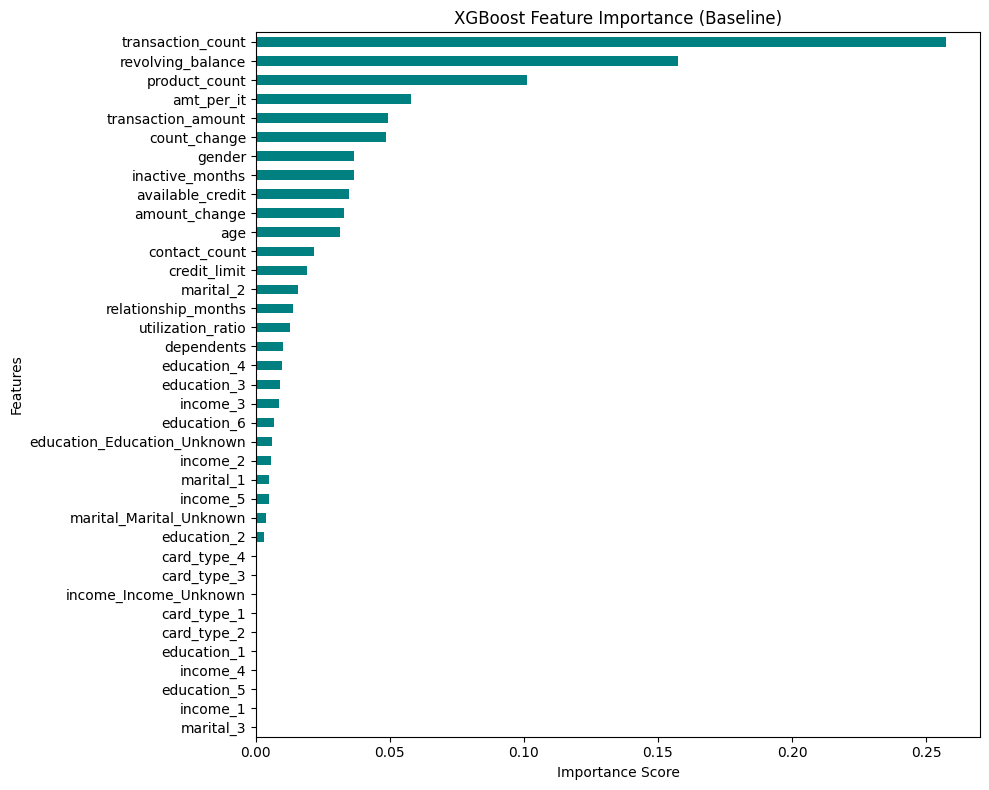

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

# 1. 데이터 불러오기
df = pd.read_csv('../JeonJongHyeok/data/df_encoded_final.csv')
df = df.drop("trans_ct_bin", axis=1)
# 2. 독립변수(X)와 종속변수(y) 분리
X = df.drop('churn', axis=1)
y = df['churn'] 

# 3. 학습 데이터와 테스트 데이터 분리 (비율 8:2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. XGBoost 모델 정의 및 학습 (1차 베이스라인)
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss' # 최신 버전에 맞춰 평가 지표 명시
)

xgb_model.fit(X_train, y_train)

# 5. 예측 및 결과 평가
y_pred = xgb_model.predict(X_test)

print(" [1차 모델 평가 결과] \n")
print(f"정확도(Accuracy): {accuracy_score(y_test, y_pred):.4f}\n")
print("분류 리포트(Classification Report):")
print(classification_report(y_test, y_pred))

# 6. 변수 중요도 시각화
plt.figure(figsize=(10, 8))
importance = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=True)
importance.plot(kind='barh', color='teal')
plt.title('XGBoost Feature Importance (Baseline)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from xgboost import XGBClassifier
import time

# 1. 최적화할 XGBoost 모델 초기화
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# ==========================================
#  방법 1: RandomizedSearchCV
# ==========================================
print("=== RandomizedSearchCV 시작 ===")
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=xgb, 
    param_distributions=param_dist, 
    n_iter=20, 
    scoring='accuracy', 
    cv=5,
    n_jobs=-1, 
    random_state=42
)

start_time = time.time()
random_search.fit(X_train, y_train)
print(f"Random Search 소요 시간: {time.time() - start_time:.2f}초")
print(f" Random Search 최고 정확도: {random_search.best_score_:.4f}")
print(f" 최적 파라미터: {random_search.best_params_}\n")


# ==========================================
#  방법 2: GridSearchCV
# ==========================================
print("=== GridSearchCV 시작 ===")
param_grid = {
    'n_estimators': [random_search.best_params_['n_estimators'], random_search.best_params_['n_estimators'] + 50],
    'learning_rate': [random_search.best_params_['learning_rate'], 0.03],
    'max_depth': [random_search.best_params_['max_depth'] - 1, random_search.best_params_['max_depth']],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb, 
    param_grid=param_grid, 
    scoring='accuracy', 
    cv=5, 
    n_jobs=-1
)

start_time = time.time()
grid_search.fit(X_train, y_train)
print(f"Grid Search 소요 시간: {time.time() - start_time:.2f}초")
print(f" Grid Search 최고 정확도: {grid_search.best_score_:.4f}")
print(f" 최종 최적 파라미터: {grid_search.best_params_}\n")

# 3. 찾은 최적의 모델로 최종 예측하기
best_xgb_model = grid_search.best_estimator_
y_pred_tuned = best_xgb_model.predict(X_test)

print(" [모델 평가 결과] ")
print(f"정확도(Accuracy): {accuracy_score(y_test, y_pred_tuned):.4f}")
print(classification_report(y_test, y_pred_tuned))

=== RandomizedSearchCV 시작 ===


/usr/local/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [08:01:03] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [08:01:03] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [08:01:03] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [08:01:03] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [08:01:03] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

Random Search 소요 시간: 16.47초
 Random Search 최고 정확도: 0.9727
 최적 파라미터: {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.6}

=== GridSearchCV 시작 ===


/usr/local/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [08:01:15] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [08:01:15] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [08:01:15] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [08:01:15] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [08:01:15] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

Grid Search 소요 시간: 46.52초
 Grid Search 최고 정확도: 0.9742
 최종 최적 파라미터: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 500, 'subsample': 1.0}

 [모델 평가 결과] 
정확도(Accuracy): 0.9748
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       325
           1       0.98      0.99      0.99      1701

    accuracy                           0.97      2026
   macro avg       0.96      0.95      0.95      2026
weighted avg       0.97      0.97      0.97      2026



In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# 1. 불균형 비율 계산 (1701 / 325 ≒ 5.23)
spw = 1701 / 325


# 2. 더 넓고 정교한 하이퍼파라미터 그리드 설정
param_grid = {
    'n_estimators': [300, 500],
    'learning_rate': [0.01, 0.05],
    'max_depth': [4, 6, 8],
    'scale_pos_weight': [1, spw, 6], 
    'gamma': [0, 0.1, 0.2],          
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(
    XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"파라미터: {grid_search.best_params_}")
print(f"F1 스코어: {grid_search.best_score_:.4f}")

/usr/local/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [08:02:02] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [08:02:02] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [08:02:02] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [08:02:02] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [08:02:02] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

KeyboardInterrupt: 

/usr/local/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [03:24:35] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


=== 1. Train vs Test 점수 비교 ===
Train F1-Score: 0.9929
Test F1-Score:  0.9518
=== 2. 상위 10개 변수 중요도 시각화 ===


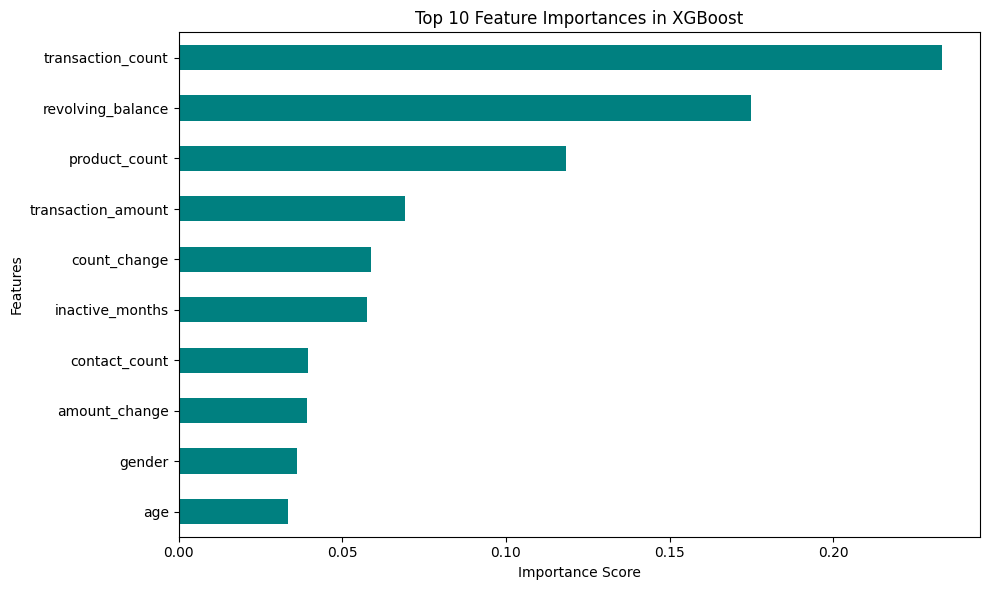

💡 해석: 가장 막대가 긴 변수들이 고객 이탈을 결정짓는 핵심 원인입니다!

=== 3. 임계값(Threshold) 하향 조정 테스트 ===
[임계값 0.3 적용 시 새로운 분류 리포트]
              precision    recall  f1-score   support

           0       0.89      0.96      0.92       325
           1       0.99      0.98      0.98      1701

    accuracy                           0.97      2026
   macro avg       0.94      0.97      0.95      2026
weighted avg       0.98      0.97      0.98      2026



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, accuracy_score, classification_report
from xgboost import XGBClassifier

# 0.파라미터
best_params = {
    'colsample_bytree': 1.0,
    'gamma': 0,
    'learning_rate': 0.05,
    'max_depth': 4,
    'n_estimators': 500,
    'scale_pos_weight': 1,
    'subsample': 0.8
}

best_xgb = XGBClassifier(**best_params, random_state=42, use_label_encoder=False, eval_metric='logloss')
best_xgb.fit(X_train, y_train)



# ==========================================
#  1. 과적합(Overfitting) 타당성 검사
# ==========================================
print("=== 1. Train vs Test 점수 비교 ===")
y_train_pred = best_xgb.predict(X_train)
y_test_pred = best_xgb.predict(X_test)

train_f1 = f1_score(y_train, y_train_pred, average='macro')
test_f1 = f1_score(y_test, y_test_pred, average='macro')

print(f"Train F1-Score: {train_f1:.4f}")
print(f"Test F1-Score:  {test_f1:.4f}")


# ==========================================
#  2. 변수 중요도 (어떤 이유로 이탈하는가?)
# ==========================================
print("=== 2. 상위 10개 변수 중요도 시각화 ===")
plt.figure(figsize=(10, 6))


importances = pd.Series(best_xgb.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=True).tail(10).plot(kind='barh', color='teal')

plt.title('Top 10 Feature Importances in XGBoost')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()
print("💡 해석: 가장 막대가 긴 변수들이 고객 이탈을 결정짓는 핵심 원인입니다!\n")


# ==========================================
# 3. 임계값(Threshold) 조정 테스트
# ==========================================
print("=== 3. 임계값(Threshold) 하향 조정 테스트 ===")

churn_probs = best_xgb.predict_proba(X_test)[:, 0]

custom_threshold = 0.3

y_pred_custom = np.where(churn_probs >= custom_threshold, 0, 1)

print(f"[임계값 {custom_threshold} 적용 시 새로운 분류 리포트]")
print(classification_report(y_test, y_pred_custom))

/usr/local/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [03:24:45] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[과적합 개선 모델 평가 결과]
Train F1-Score: 0.9629
Test F1-Score:  0.9476
두 점수의 차이(Gap): 0.0153


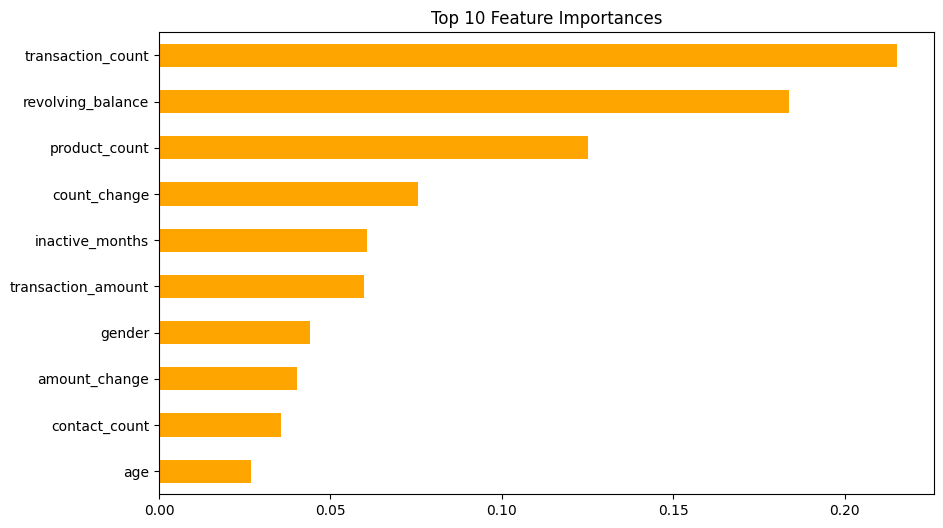

In [ ]:
# 과적합 의심되어 다시 조정해서 학습
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, classification_report
import matplotlib.pyplot as plt
import pandas as pd

# 1.파라미터
tuned_params = {
    'colsample_bytree': 1.0,
    'gamma': 0.5,           
    'learning_rate': 0.05,
    'max_depth': 3,         
    'n_estimators': 300,    
    'scale_pos_weight': 1,
    'subsample': 0.8
}

# 2. 수정된 모델 생성 및 학습
diet_xgb = XGBClassifier(**tuned_params, random_state=42, use_label_encoder=False, eval_metric='logloss')
diet_xgb.fit(X_train, y_train)

# 3. 결과 평가
y_train_pred = diet_xgb.predict(X_train)
y_test_pred = diet_xgb.predict(X_test)

train_f1 = f1_score(y_train, y_train_pred, average='macro')
test_f1 = f1_score(y_test, y_test_pred, average='macro')

print("[과적합 개선 모델 평가 결과]")
print(f"Train F1-Score: {train_f1:.4f}")
print(f"Test F1-Score:  {test_f1:.4f}")
print(f"두 점수의 차이(Gap): {abs(train_f1 - test_f1):.4f}")


# 4. 변수 중요도 다시 확인
plt.figure(figsize=(10, 6))
importances = pd.Series(diet_xgb.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=True).tail(10).plot(kind='barh', color='orange')
plt.title('Top 10 Feature Importances')
plt.show()

In [ ]:
# 감마 조정해서 다시
from xgboost import XGBClassifier
from sklearn.metrics import f1_score

# 1. 파라미터
golden_params = {
    'colsample_bytree': 1.0,
    'gamma': 0.2,           
    'learning_rate': 0.05,
    'max_depth': 4,         
    'n_estimators': 400,    
    'scale_pos_weight': 1,
    'subsample': 0.8
}

# 2. 모델 생성 및 학습
golden_xgb = XGBClassifier(**golden_params, random_state=42, use_label_encoder=False, eval_metric='logloss')
golden_xgb.fit(X_train, y_train)

# 3. 결과 확인
y_train_pred = golden_xgb.predict(X_train)
y_test_pred = golden_xgb.predict(X_test)

train_f1 = f1_score(y_train, y_train_pred, average='macro')
test_f1 = f1_score(y_test, y_test_pred, average='macro')

print(" [모델 결과] ")
print(f"Train F1-Score: {train_f1:.4f}")
print(f"Test F1-Score:  {test_f1:.4f}")
print(f"두 점수의 차이(Gap): {abs(train_f1 - test_f1):.4f}")

/usr/local/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [03:24:54] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


 [모델 결과] 
Train F1-Score: 0.9871
Test F1-Score:  0.9498
두 점수의 차이(Gap): 0.0373


In [ ]:
# train 과 test 간극 좁히기
from xgboost import XGBClassifier
from sklearn.metrics import f1_score

# 1.파라미터
final_params = {
    'colsample_bytree': 1.0,
    'gamma': 0.3,           
    'learning_rate': 0.05,
    'max_depth': 4,         
    'n_estimators': 300,    
    'reg_lambda': 1.0,     
    'scale_pos_weight': 1,
    'subsample': 0.8
}

# 2. 모델 생성 및 학습
final_xgb = XGBClassifier(**final_params, random_state=42, use_label_encoder=False, eval_metric='logloss')
final_xgb.fit(X_train, y_train)

# 3. 결과 확인
y_train_pred = final_xgb.predict(X_train)
y_test_pred = final_xgb.predict(X_test)

train_f1 = f1_score(y_train, y_train_pred, average='macro')
test_f1 = f1_score(y_test, y_test_pred, average='macro')

print("[진짜 최종 타겟팅 모델 결과]")
print(f"Train F1-Score: {train_f1:.4f}")
print(f"Test F1-Score:  {test_f1:.4f}")
print(f"두 점수의 차이(Gap): {abs(train_f1 - test_f1):.4f}")

/usr/local/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [03:25:04] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[진짜 최종 타겟팅 모델 결과]
Train F1-Score: 0.9790
Test F1-Score:  0.9508
두 점수의 차이(Gap): 0.0283


In [ ]:
# 모델 객체가 메모리에 있는지 확인
print(final_xgb) 

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=0.3, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)
